In [39]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import library for splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import evaluation metrics for classification models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
# Loading the dataset
import pandas as pd

df = pd.read_csv('/content/hotel_bookings.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [41]:
# Display dataset information such as
# column names, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [42]:
# Display number of unique values in each column

df.nunique()

,0
hotel,2
is_canceled,2
lead_time,479
arrival_date_year,3
arrival_date_month,12
arrival_date_week_number,53
arrival_date_day_of_month,31
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [43]:
# Check for missing values in each column

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [44]:
# Replace missing values with 0

df = df.fillna(0)

In [45]:
# Verify that no missing values remain

df.isnull().sum().sum()

np.int64(0)

In [46]:
# Remove duplicate records from dataset

df = df.drop_duplicates()

In [47]:
# Verify duplicates have been removed

df.duplicated().sum()

np.int64(0)

In [48]:
# Check the distribution of cancelled and non-cancelled bookings

df['is_canceled'].value_counts()

,count
is_canceled,
0,63371
1,24025


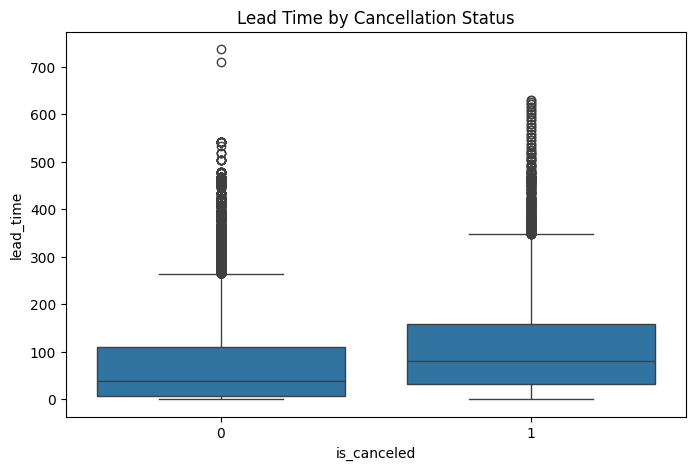

In [49]:
# Box Plot

plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='lead_time',
    data=df
)

plt.title('Lead Time by Cancellation Status')

plt.show()

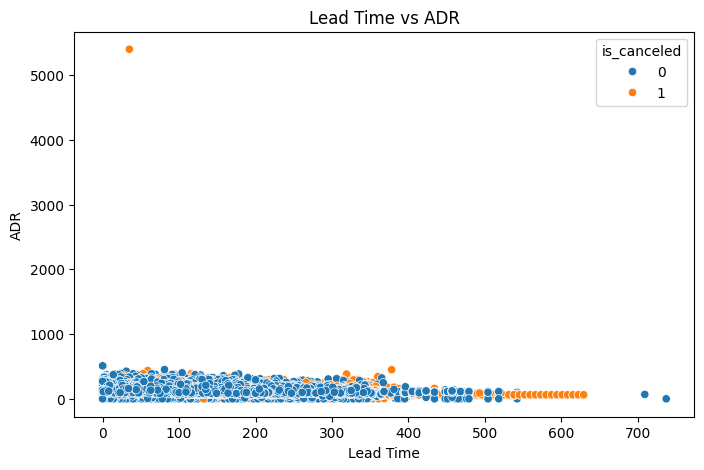

In [50]:
# Scatter Plot: Lead Time vs ADR

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='lead_time',
    y='adr',
    hue='is_canceled'
)

plt.title('Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')

plt.show()

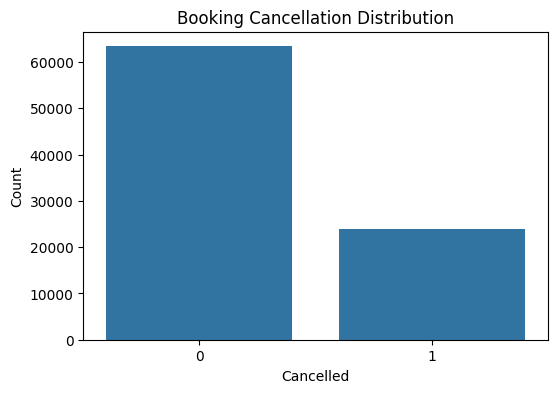

In [51]:
# Count Plot for Cancellation Status

plt.figure(figsize=(6,4))

sns.countplot(
    x='is_canceled',
    data=df
)

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancelled')
plt.ylabel('Count')

plt.show()

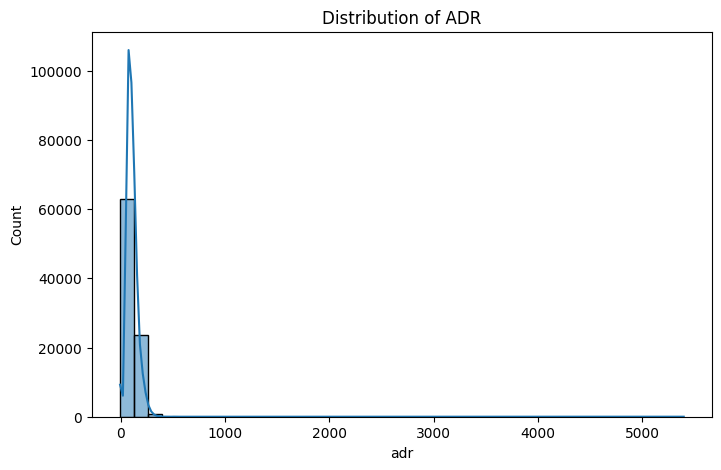

In [52]:
# Histogram of ADR

plt.figure(figsize=(8,5))

sns.histplot(
    df['adr'],
    bins=40,
    kde=True
)

plt.title('Distribution of ADR')

plt.show()

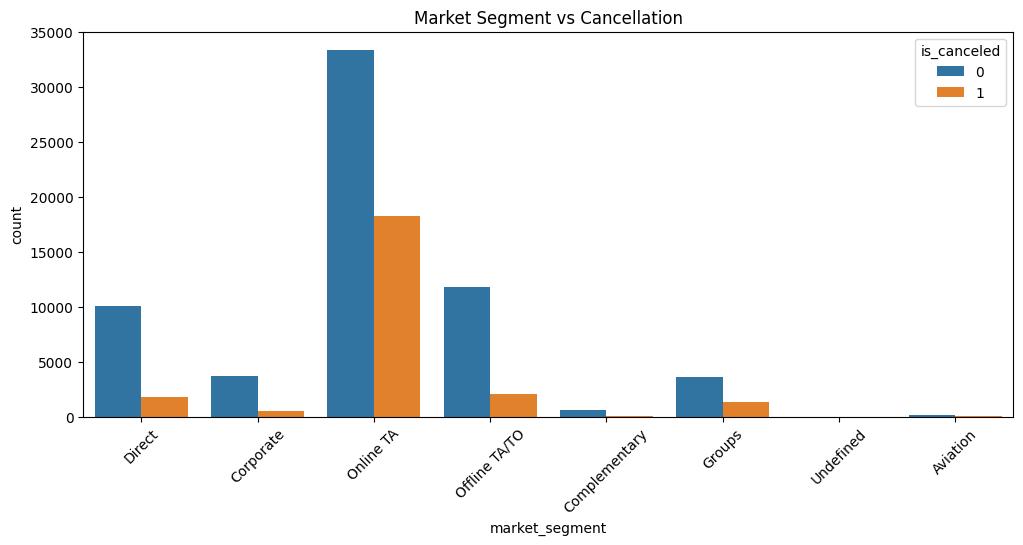

In [53]:
# Analyze cancellations across market segments

plt.figure(figsize=(12,5))

sns.countplot(
    x='market_segment',
    hue='is_canceled',
    data=df
)

plt.xticks(rotation=45)

plt.title('Market Segment vs Cancellation')

plt.show()

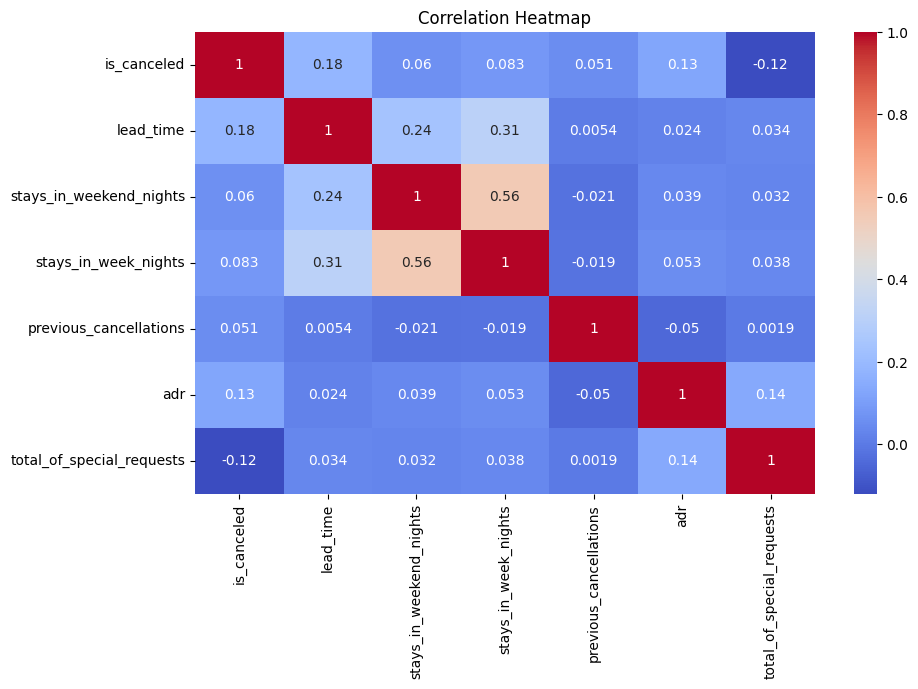

In [54]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

corr = df[
[
'is_canceled',
'lead_time',
'stays_in_weekend_nights',
'stays_in_week_nights',
'previous_cancellations',
'adr',
'total_of_special_requests'
]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [55]:
# Convert categorical columns into numerical columns

df_encoded = pd.get_dummies(df, drop_first=True)

In [56]:
# Features

X = df_encoded.drop('is_canceled', axis=1)

# Target

y = df_encoded['is_canceled']

In [57]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [58]:
# Logistic Regression Model

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

print("========== Logistic Regression ==========")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


========== Logistic Regression ==========
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12733
           1       1.00      1.00      1.00      4747

    accuracy                           1.00     17480
   macro avg       1.00      1.00      1.00     17480
weighted avg       1.00      1.00      1.00     17480



In [59]:
# Random Forest Classifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

print("========== Random Forest ==========")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

========== Random Forest ==========
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12733
           1       1.00      1.00      1.00      4747

    accuracy                           1.00     17480
   macro avg       1.00      1.00      1.00     17480
weighted avg       1.00      1.00      1.00     17480



In [60]:
# XGBoost Classifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb.predict(
    X_test
)

print("========== XGBoost ==========")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

========== XGBoost ==========
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12733
           1       1.00      1.00      1.00      4747

    accuracy                           1.00     17480
   macro avg       1.00      1.00      1.00     17480
weighted avg       1.00      1.00      1.00     17480



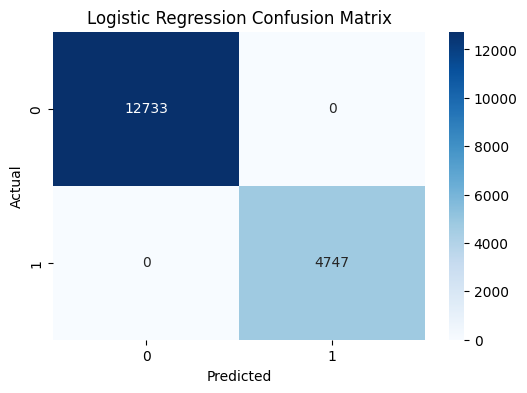

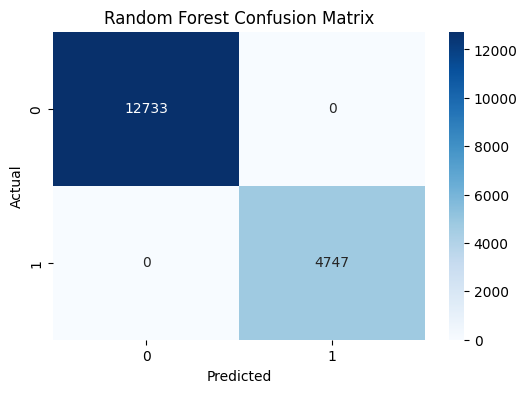

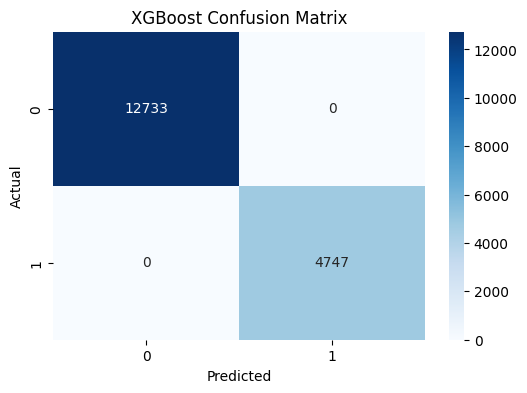

In [61]:
# Confusion Matrices for All Models

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, predictions in models.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} Confusion Matrix')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

In [62]:
# Compare model performance

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    "XGBoost Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0


In [63]:
# Identify most important factors influencing cancellations

feature_importance = pd.DataFrame(
{
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}
)

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                          Feature  Importance
248  reservation_status_Check-Out    0.603645
0                       lead_time    0.035541
18      total_of_special_requests    0.021958
16                            adr    0.018291
170                   country_PRT    0.017413
13                          agent    0.017306
17    required_car_parking_spaces    0.014670
217      market_segment_Online TA    0.013806
249    reservation_status_No-Show    0.010636
2        arrival_date_week_number    0.010537


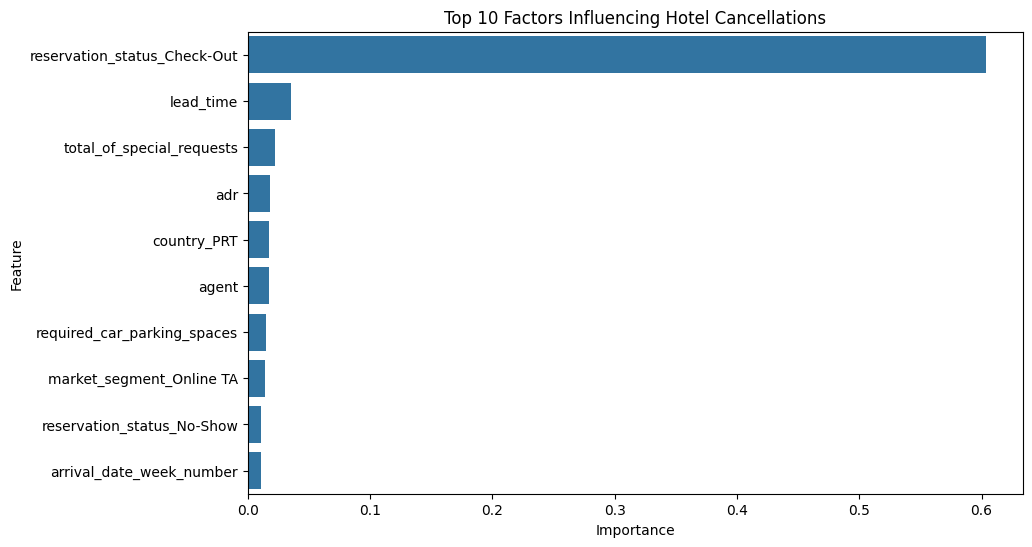

In [64]:
# Plot top 10 important features

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title(
    'Top 10 Factors Influencing Hotel Cancellations'
)

plt.show()

Conclusion

1. Lead Time is one of the strongest indicators of hotel booking cancellations.

2. Previous cancellations significantly increase the likelihood of future cancellations.

3. Customers with more special requests are less likely to cancel bookings.

4. Random Forest and XGBoost outperformed Logistic Regression.

5. Machine learning models can help hotels identify high-risk bookings and reduce revenue loss due to cancellations.